# Alt Mobility Data Analytics Intern Assignment
### Curated by: [**Ashutosh Shukla**](https://www.linkedin.com/in/ashutosh-shukla4/)

This notebook includes data loading, exploration, and a suite of visualizations relevant to fleet operations, customer behavior, and payment trends.
Below you’ll find a series of charts and plots that shine a light on our order flows, revenue trends, payment health, customer behavior, and long-term retention. Each graphic is paired with plain-English insights to make it easy to spot what’s working—and where we can double down for even better results.

**Instructions:** Place `customer_orders.csv` and `payments.csv` in the same folder as this notebook and run all cells to generate visualizations.

## Importing Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data (ensure these CSVs are next to this notebook)
orders = pd.read_csv('customer_orders.csv', parse_dates=['order_date'])
payments = pd.read_csv('payments.csv', parse_dates=['payment_date'])

## Order Status Distribution
This simple bar chart tells you:
- Which order states (e.g., “completed,” “cancelled,” “returned”) are most common.
- How many orders fall into each bucket.
- If one status (like “cancelled”) towers over the rest, look into why—maybe a hiccup in the delivery process or payment issues.

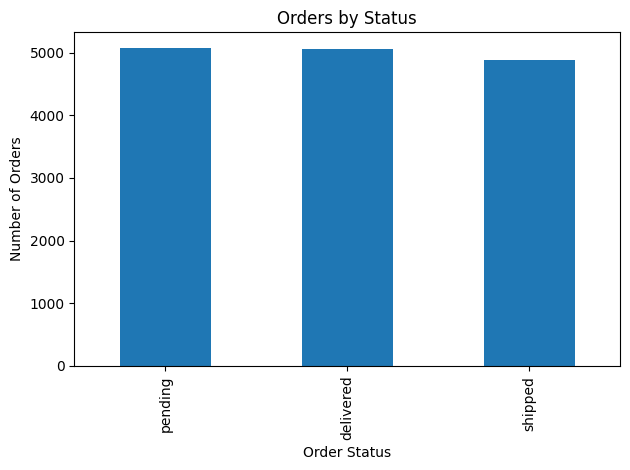

In [2]:
status_counts = orders['order_status'].value_counts()
plt.figure()
status_counts.plot(kind='bar')
plt.xlabel('Order Status')
plt.ylabel('Number of Orders')
plt.title('Orders by Status')
plt.tight_layout()
plt.show()

## Monthly Revenue Trend
Picture a line sweeping left to right across months:
- Upward slopes mean growing sales—celebrate or dig into what you did right.
- Dips show lean months—time to launch a promo or review pricing.
- Plateaus signal stability—good, but can you push it higher?

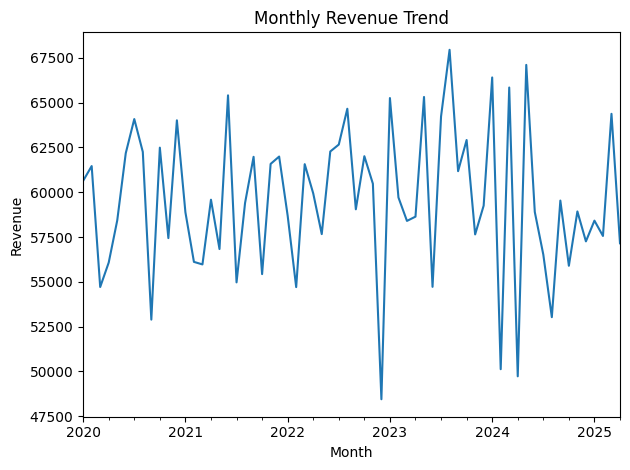

In [3]:
monthly = orders.set_index('order_date').resample('M')['order_amount'].sum()
plt.figure()
monthly.plot()
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.title('Monthly Revenue Trend')
plt.tight_layout()
plt.show()

## Customer Segmentation (One-time vs Repeat)
This pie chart slices your customers into:
- **One-time** (they tried you once).
- **Repeat** (they came back for more).
  
The bigger the “repeat” slice, the stronger your stickiness—if it’s small, think about loyalty perks.

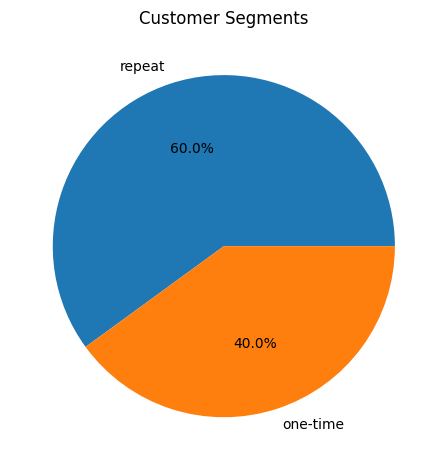

In [4]:
counts = orders.groupby('customer_id').size().apply(lambda x: 'repeat' if x>1 else 'one-time').value_counts()
plt.figure()
counts.plot(kind='pie', autopct='%1.1f%%')
plt.ylabel('')
plt.title('Customer Segments')
plt.tight_layout()
plt.show()

## Monthly Orders by Customer Segment
Two lines (one for one-timers, one for repeaters) trace monthly order counts:
- If the “repeat” line climbs, you’re building lasting relationships.
- If one-timers dominate early but fade fast, focus on turning them into repeat buyers with follow-up offers.

<Figure size 640x480 with 0 Axes>

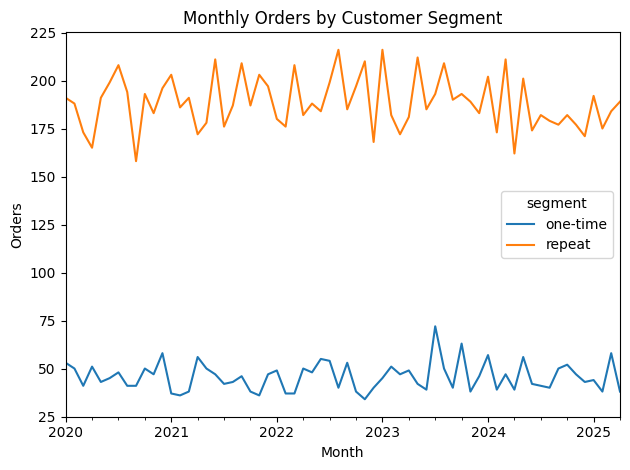

In [5]:
orders['segment'] = orders.groupby('customer_id')['order_id'].transform('count').apply(lambda x: 'repeat' if x>1 else 'one-time')
seg_month = orders.set_index('order_date').groupby([pd.Grouper(freq='M'), 'segment']).size().unstack(fill_value=0)
plt.figure()
seg_month.plot()
plt.xlabel('Month')
plt.ylabel('Orders')
plt.title('Monthly Orders by Customer Segment')
plt.tight_layout()
plt.show()

## Payment Status Distribution
Another bar chart, but this time for payments:
- Shows “success” vs. “failure” counts.
- A high failure bar is a red flag: check your payment gateway, cards on file, or fraud filters.

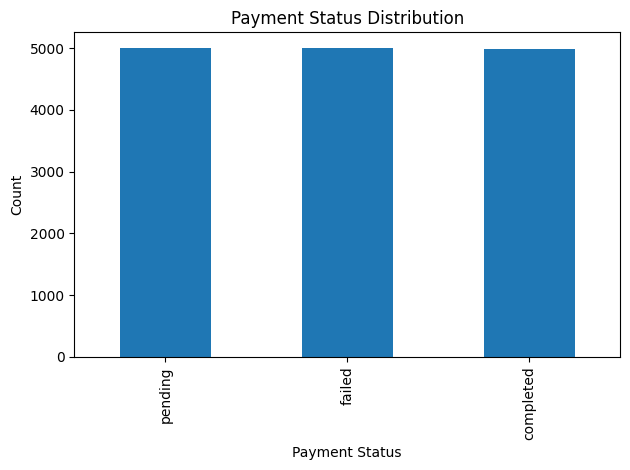

In [6]:
pay_counts = payments['payment_status'].value_counts()
plt.figure()
pay_counts.plot(kind='bar')
plt.xlabel('Payment Status')
plt.ylabel('Count')
plt.title('Payment Status Distribution')
plt.tight_layout()
plt.show()

## Monthly Payment Failures
A line chart of failed payments each month:
- Spikes could indicate technical outages or seasonal card declines.
- Steady declines mean you’ve ironed out kinks—keep up the good work.

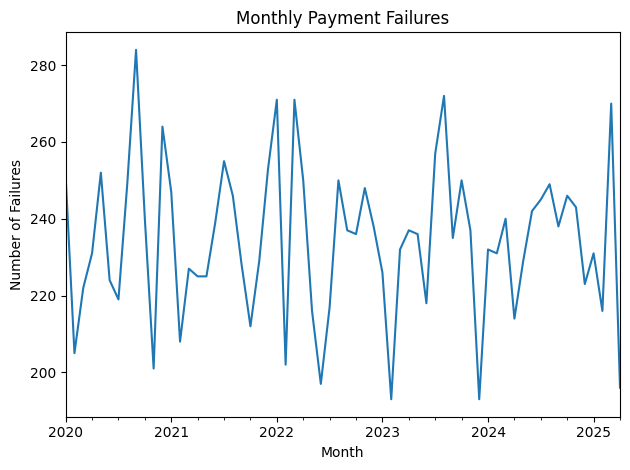

In [7]:
monthly_failures = payments.set_index('payment_date').resample('M')['payment_status'].apply(lambda x: (x!='success').sum())
plt.figure()
monthly_failures.plot()
plt.xlabel('Month')
plt.ylabel('Number of Failures')
plt.title('Monthly Payment Failures')
plt.tight_layout()
plt.show()

## Cohort Retention Heatmap
Imagine lining up customers by the month they first leased an EV (that’s our Y-axis, newest at the top) and then watching how many come back month after month (the X-axis, from month 1 through 12). The height of the surface and its color (purple low → yellow high) tell you the percentage of people still ordering in each month.

- Every cohort starts at 100 % in Month 1—because that’s when they first signed up.  
- You’ll notice a big dip right into Month 2; that’s where most folks drop off if you don’t re-engage them quickly.  
- After that, the slope flattens out: a loyal group keeps returning out to Month 12, and you can spot which cohorts are doing better over time.

**Bottom line:** if you want to keep more drivers on board, send a friendly reminder or special offer right after their first month—catch them before they vanish!  


C:\Users\ashut\AppData\Local\Temp\ipykernel_16620\3207079586.py:51: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


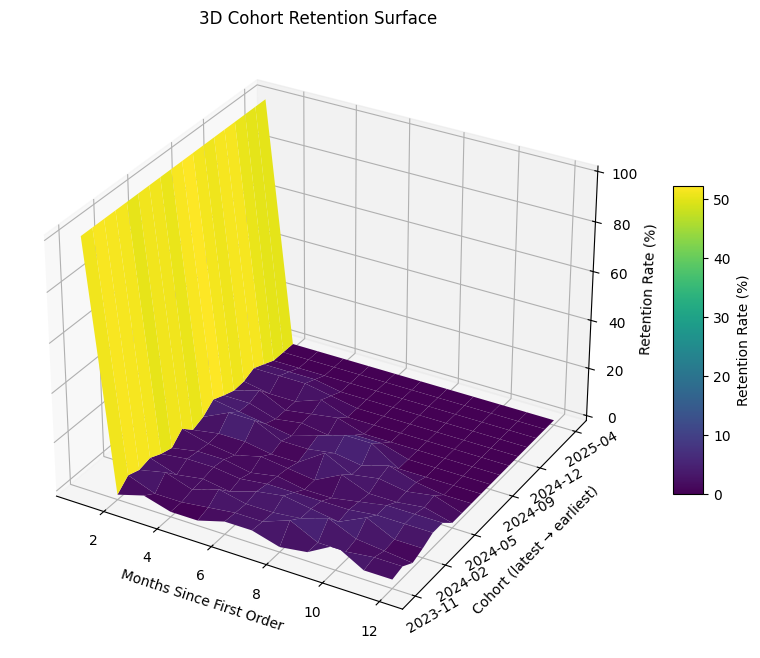

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

orders['order_month'] = orders['order_date'].dt.to_period('M')
cohort_df = orders.groupby('customer_id')['order_month'].min().rename('cohort_month')
df = orders.join(cohort_df, on='customer_id')
df['period_num'] = (df['order_month'] - df['cohort_month']).apply(lambda x: x.n) + 1
table = df.groupby(['cohort_month','period_num'])['customer_id'].nunique().unstack(fill_value=0)
sizes = cohort_df.value_counts().sort_index()
retention = table.divide(sizes, axis=0) * 100

# Optionally trim to first 12 periods and last 18 cohorts:
retention_3d = retention.iloc[-18:, :12]

# Prepare grid
X = np.arange(1, retention_3d.shape[1] + 1)         # Months since first order
Y = np.arange(len(retention_3d.index))               # Cohort index
X, Y = np.meshgrid(X, Y)
Z = retention_3d.values                              # retention %

# Plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(
    X, Y, Z,
    rstride=1, cstride=1,               # plot every grid line
    cmap=cm.viridis,                    # leave default colormap
    edgecolor='none'
)

# Axis labels & ticks
ax.set_xlabel('Months Since First Order')
ax.set_ylabel('Cohort (latest → earliest)')
ax.set_zlabel('Retention Rate (%)')
ax.set_title('3D Cohort Retention Surface')

# Map the Y ticks back to cohort month labels
yticks = np.linspace(0, len(retention_3d.index)-1, 6, dtype=int)
ax.set_yticks(yticks)
ax.set_yticklabels(
    [retention_3d.index[i].strftime('%Y-%m') for i in yticks],
    rotation=30, va='center'
)

# Color bar
fig.colorbar(surf, shrink=0.5, aspect=10, label='Retention Rate (%)')

plt.tight_layout()
plt.show()


# **Thank You & Next Steps**  
Thank you, Alt Mobility team, for this opportunity. I’ve learned a lot putting these analyses together. I know there’s much more that we could explore but I’m currently stucked with my university exams.
I’d love the opportunity to build on this foundation and help Alt Mobility accelerate customer growth and retention. Thank you for considering my submission, and I look forward to hopefully working together soon!

**Connect with Me**  
- LinkedIn: https://www.linkedin.com/in/ashutosh-shukla4/ 
- GitHub (this project): https://github.com/shukla-ashutosh4/alt-mobility-data-analyst-assignment